In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split



from qae_qknn import QAEConfig, QuantumAutoencoder
from preprocessing import timed_preprocess

/Users/nicoletadobrica/AQA_QDL/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
prep = timed_preprocess(percent10=True, n_components=4, vis_samples=1000)

X_train = prep["X_train_pca"]
X_test = prep["X_test_pca"]
y_train = prep["y_train"]
y_test = prep["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)

KDD99 preprocessing time: 12.70s
Full train: (155644, 4)
Full test:  (98805, 4)


In [3]:
X_train_qae_full, X_val_qae, y_train_qae_full, y_val_qae = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

rng = np.random.default_rng(42)

train_subset_size = 6000 # 6000
train_idx = rng.choice(len(X_train_qae_full), size=train_subset_size, replace=False)
X_train_qae = X_train_qae_full[train_idx]
y_train_qae = y_train_qae_full[train_idx]

val_subset_size = 650 # 650
val_idx = rng.choice(len(X_val_qae), size=val_subset_size, replace=False)
X_val_qae_small = X_val_qae[val_idx]
y_val_qae_small = y_val_qae[val_idx]

print("QAE train subset:", X_train_qae.shape)
print("QAE val subset:  ", X_val_qae_small.shape)

QAE train subset: (6000, 4)
QAE val subset:   (650, 4)


In [ ]:
config = QAEConfig(
    n_qubits=4,
    n_latent=2,
    n_layers=1,
    device_name="default.qubit",
    seed=42,
    use_swap_test_loss=True,
    use_log_cost=True,
)

qae = QuantumAutoencoder(config)

best_params, history, scaler = qae.train(
    X_train_raw=X_train_qae,
    X_val_raw=X_val_qae_small,
    steps=80,  
    lr=0.03,
    batch_size=32, 
    val_every=10, 
    verbose=True,
)

[Step 000] train_loss=-0.145103 | val_loss=-0.170801
[Step 005] train_loss=-0.191523
[Step 010] train_loss=-0.256723 | val_loss=-0.251975
[Step 015] train_loss=-0.339492
[Step 020] train_loss=-0.308618 | val_loss=-0.338886
[Step 025] train_loss=-0.337087
[Step 030] train_loss=-0.473075 | val_loss=-0.393989
[Step 035] train_loss=-0.338344
[Step 040] train_loss=-0.434210 | val_loss=-0.403045
[Step 045] train_loss=-0.438847
[Step 050] train_loss=-0.274667 | val_loss=-0.405578
[Step 055] train_loss=-0.463461
[Step 060] train_loss=-0.391426 | val_loss=-0.409297
[Step 065] train_loss=-0.470605
[Step 070] train_loss=-0.501189 | val_loss=-0.409764
[Step 075] train_loss=-0.445320
[Step 079] train_loss=-0.400680 | val_loss=-0.410356


In [5]:
qae.save_checkpoint(
    "qae_checkpoint.npz",
    params=best_params,
    scaler=scaler,
    history=history,
    extra_metadata={"dataset": "KDDCup99 PCA-4"}
)

In [ ]:
# these subsets are not actually used for training, they are leftover from a previous version and get updated later in the notebook
qknn_train_size = 2000
qknn_test_size = 400

train_idx_small = rng.choice(len(X_train), size=qknn_train_size, replace=False)
test_idx_small = rng.choice(len(X_test), size=qknn_test_size, replace=False)

X_train_small = X_train[train_idx_small]
y_train_small = y_train[train_idx_small]

X_test_small = X_test[test_idx_small]
y_test_small = y_test[test_idx_small]

In [7]:
from collections import Counter
def qknn_predict(fidelity_matrix, y_train, k=3):
    y_pred = []
    y_prob = []

    for row in fidelity_matrix:
        idx = np.argsort(row)[-k:]
        labels = y_train[idx]
        y_pred.append(Counter(labels).most_common(1)[0][0])
        y_prob.append(np.mean(labels))

    return np.array(y_pred), np.array(y_prob)

In [8]:
qknn_test_n = 100
qknn_train_n = 500
print("Compressing datasets using trained QAE...")
y_tr_labels = y_train_small[:qknn_train_n]
y_te_true = y_test_small[:qknn_test_n]
X_train_latent = qae.batch_transform_latent_features_from_raw(
    X_train_small[:qknn_train_n], best_params, scaler, verbose=False
)

X_test_latent = qae.batch_transform_latent_features_from_raw(
    X_test_small[:qknn_test_n], best_params, scaler, verbose=False
)

print(f"Original shape: {X_train_small.shape}") 
print(f"Latent shape:   {X_train_latent.shape}") 

Compressing datasets using trained QAE...
Original shape: (2000, 4)
Latent shape:   (500, 2)


In [ ]:
import pennylane as qml

def build_qknn(n_latent):
    # Wires: 1 ancilla + 2 * n_latent
    dev = qml.device("default.qubit", wires=1 + 2 * n_latent)

    @qml.qnode(dev)
    def circuit(state_vec1, state_vec2):
        ancilla = 0
        reg1 = list(range(1, n_latent + 1))
        reg2 = list(range(n_latent + 1, 2 * n_latent + 1))
        qml.StatePrep(state_vec1, wires=reg1)
        qml.StatePrep(state_vec2, wires=reg2)
        qml.Hadamard(wires=ancilla)
        for i in range(n_latent):
            qml.CSWAP(wires=[ancilla, reg1[i], reg2[i]])
        qml.Hadamard(wires=ancilla)

        return qml.probs(wires=[ancilla])

    return circuit

In [ ]:
X_train_latent_states = qae.get_all_latent_states(
    X_train_small[:qknn_train_n], best_params, scaler
)

X_test_latent_states = qae.get_all_latent_states(
    X_test_small[:qknn_test_n], best_params, scaler
)

qknn_circuit = build_qknn(qae.config.n_latent)

def compute_fidelity(states_test, states_train):
    n_test, n_train = len(states_test), len(states_train)
    f_matrix = np.zeros((n_test, n_train))
    for i in range(n_test):
        for j in range(n_train):
            probs = qknn_circuit(states_test[i], states_train[j])
            f_matrix[i, j] = np.clip(2 * probs[0] - 1, 0.0, 1.0)
        if (i + 1) % 20 == 0:
            print(f"Processed {i+1}/{n_test}")
    return f_matrix

F = compute_fidelity(X_test_latent_states, X_train_latent_states)
y_pred_qknn, y_prob_qknn = qknn_predict(F, y_tr_labels, k=3)

Processed 20/100
Processed 40/100
Processed 60/100
Processed 80/100
Processed 100/100



Accuracy: 0.9800 | ROC-AUC: 0.9864


,precision,recall,f1-score,support
normal,0.900,1.0000,0.9474,18.00
attack,1.000,0.9756,0.9877,82.00
accuracy,0.980,0.9800,0.9800,0.98
macro avg,0.950,0.9878,0.9675,100.00
weighted avg,0.982,0.9800,0.9804,100.00


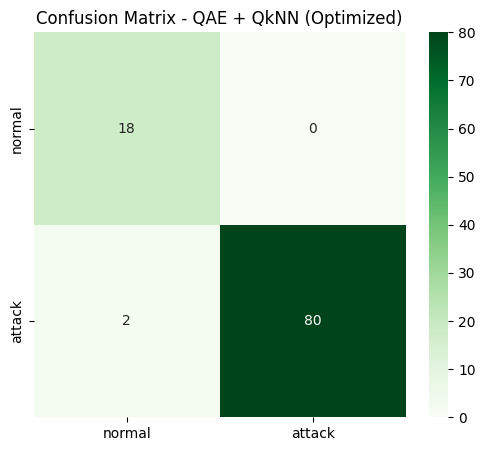

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)

y_te_true_int = np.array(y_te_true, dtype=int)
y_pred_qknn_int = np.array(y_pred_qknn, dtype=int)

acc_qknn = accuracy_score(y_te_true_int, y_pred_qknn_int)
auc_qknn = roc_auc_score(y_te_true_int, y_prob_qknn)
cm_qknn = confusion_matrix(y_te_true_int, y_pred_qknn_int)

report_qknn = pd.DataFrame(classification_report(
    y_te_true_int,
    y_pred_qknn_int,
    target_names=["normal", "attack"],
    output_dict=True
)).T

print(f"\nAccuracy: {acc_qknn:.4f} | ROC-AUC: {auc_qknn:.4f}")
display(report_qknn.round(4))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qknn, annot=True, fmt="d", cmap="Greens",
            xticklabels=["normal", "attack"],
            yticklabels=["normal", "attack"])
plt.title("Confusion Matrix - QAE + QkNN")
plt.show()



